# Aufgabe 3: SciQ-Scorecards-Chatbot

## Beschreibung

In dieser Aufgabe wird ein Chatbot zur Beantwortung naturwissenschaftlicher Multiple-Choice-Fragen auf Basis des Datensatzes `allenai/sciq` entwickelt. Zu jeder Frage gibt es 4 Antwortoptionen – das System soll die wahrscheinlich richtige auswählen.

### Lösungsansatz

Der Lösungsweg gliedert sich in folgende Schritte:

1. **Datensatz laden und erkunden** – Der SciQ-Datensatz enthält 11.679 Trainings-, 1.000 Validierungs- und 1.000 Testbeispiele. Jedes Beispiel besteht aus einer Frage, einem Support-Text (Hintergrundinformation), der korrekten Antwort und drei Distraktoren (falschen Antworten).

2. **Tokenizer und Embedding-Matrix** – Der Tokenizer von `bert-base-uncased` zerlegt Texte in Token-IDs. Die **Eingabe-Embedding-Matrix** von BERT (30.522 × 768) ordnet jeder Token-ID einen 768-dimensionalen Vektor zu. Wichtig: Es wird **kein** BERT-Encoder verwendet – nur die statische Embedding-Matrix.

3. **Textvektoren durch Mittelwert-Pooling** – Jeder Text wird tokenisiert und in eine Folge von Embedding-Vektoren umgewandelt. Der Mittelwert über alle Token ergibt einen festen 768-dimensionalen Textvektor. Leere Texte ergeben einen Nullvektor (verhindert NaN).

4. **Merkmalsvektor pro Kontext-Antwort-Paar** – Für jede der 4 Antwortoptionen wird ein 3072-dimensionaler Merkmalsvektor aus Kontext- und Antwortvektor gebaut: `concat(kontext, antwort, |kontext−antwort|, kontext⊙antwort)`. Die Differenz und das Produkt liefern dem MLP direkte Vergleichsinformation.

5. **Dataset mit Permutationslogik** – Die Antworten werden für jedes Beispiel permutiert, damit das Modell nicht lernt, dass die korrekte Antwort immer an Position 0 steht. Das Label ist die neue Position der ursprünglich korrekten Antwort nach der Permutation.

6. **MLP-Modell** – Ein kleines MLP (3072 → 512 → 1) bewertet jede Antwortoption mit einem Score. Alle 4 Optionen werden gemeinsam durch das MLP geschickt (Reshape auf `B*4`), dann zu `(B, 4)` zurückgeformt. `CrossEntropyLoss` auf den rohen Logits wählt die beste Antwortoption aus.

7. **Training** – AdamW mit Weight Decay verhindert Overfitting. Das beste Modell (höchste Validation Accuracy) wird gespeichert. Das Ziel ist ≥70% Accuracy auf Training- und Testdaten.

8. **ask_bot** – Eine Inferenzfunktion, die zu einer Frage und 4 Optionen die wahrscheinlichste Antwort ausgibt, inklusive Wahrscheinlichkeiten aller Optionen.

### Kritische Vorgaben (aus Handout)
- **Nur Input-Embeddings**: `hf_model(**inputs)`, Hidden States und Pooler sind verboten
- **Kein Softmax vor CrossEntropyLoss**: `nn.CrossEntropyLoss` erwartet rohe Logits
- **Support-Text einbeziehen**: Kontext = Frage-Tokens + Support-Tokens zusammen
- **Label nach Permutation**: `label = perm.index(0)` – neue Position der korrekten Antwort

### System-Übersicht
- **Datensatz**: allenai/sciq
- **Textrepräsentation**: Mittelwert der festen BERT Input-Embeddings (768-dim)
- **Merkmalsvektor**: 4 × 768 = 3072-dim pro Kontext-Antwort-Paar
- **Modell**: MLP (3072 → 512 → 1 Score)
- **Ziel**: ≥70% Accuracy auf Training- und Testdaten

## 1. Imports und Konstanten

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
import numpy as np
import random
import matplotlib.pyplot as plt
import gc
import os

print(f"PyTorch: {torch.__version__}")
print(f"GPU verfügbar: {torch.cuda.is_available()}")

# ---- Hyperparameter (exakt nach Handout Infos.md) ----
MODEL_NAME    = "bert-base-uncased"
MAX_Q         = 48    # Max Tokens für Frage
MAX_S         = 96    # Max Tokens für Support
MAX_A         = 28    # Max Tokens für Antwort
EMBED_DIM     = 768   # BERT Embedding-Dimension
FEATURE_DIM   = 4 * EMBED_DIM  # = 3072 (Kontext + Antwort + Diff + Produkt)
HIDDEN_DIM    = 512
DROPOUT       = 0.30
BATCH_SIZE    = 16
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-2
EPOCHS        = 50
SEED          = 42
BEST_MODEL_PATH = 'best_sciq_model.pt'

# Gerät bestimmen
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Gerät: {DEVICE}")

# Reproduzierbarkeit
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PyTorch: 2.11.0
GPU verfügbar: False
Gerät: cpu


## 2. Datensatz laden und erkunden

In [17]:
# SciQ-Datensatz laden
dataset    = load_dataset("allenai/sciq")
train_split = dataset["train"]
val_split   = dataset["validation"]
test_split  = dataset["test"]

print(f"Train: {len(train_split)} Beispiele")
print(f"Validation: {len(val_split)} Beispiele")
print(f"Test: {len(test_split)} Beispiele")

# Beispiele erkunden
print("\n" + "="*60)
print("BEISPIEL AUS DEM TRAININGSDATENSATZ:")
print("="*60)
for i in range(3):
    ex = train_split[i]
    print(f"\nBeispiel {i+1}:")
    print(f"  Frage:      {ex['question']}")
    print(f"  Support:    {ex['support'][:100]}..." if ex['support'] else "  Support:    (leer)")
    print(f"  Korrekt:    {ex['correct_answer']}")
    print(f"  Distraktor1: {ex['distractor1']}")
    print(f"  Distraktor2: {ex['distractor2']}")
    print(f"  Distraktor3: {ex['distractor3']}")

Train: 11679 Beispiele
Validation: 1000 Beispiele
Test: 1000 Beispiele

BEISPIEL AUS DEM TRAININGSDATENSATZ:

Beispiel 1:
  Frage:      What type of organism is commonly used in preparation of foods such as cheese and yogurt?
  Support:    Mesophiles grow best in moderate temperature, typically between 25°C and 40°C (77°F and 104°F). Meso...
  Korrekt:    mesophilic organisms
  Distraktor1: protozoa
  Distraktor2: gymnosperms
  Distraktor3: viruses

Beispiel 2:
  Frage:      What phenomenon makes global winds blow northeast to southwest or the reverse in the northern hemisphere and northwest to southeast or the reverse in the southern hemisphere?
  Support:    Without Coriolis Effect the global winds would blow north to south or south to north. But Coriolis m...
  Korrekt:    coriolis effect
  Distraktor1: muon effect
  Distraktor2: centrifugal effect
  Distraktor3: tropical effect

Beispiel 3:
  Frage:      Changes from a less-ordered state to a more-ordered state (such as a liquid to

## 3. Tokenizer und Embedding-Matrix laden

**Kritische Vorgabe aus dem Handout**: Es wird NUR die Eingabe-Embedding-Matrix verwendet.
- `hf_model(**inputs)` ist verboten
- `last_hidden_state` ist verboten  
- `pooler_output` ist verboten
- Nur `get_input_embeddings().weight` ist erlaubt

In [18]:
# Tokenizer laden
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer geladen: {MODEL_NAME}")
print(f"Vokabular-Größe: {tokenizer.vocab_size}")

# Modell NUR für Embedding-Matrix laden
print("\nLade bert-base-uncased für Embedding-Matrix...")
hf_model = AutoModel.from_pretrained(MODEL_NAME)

# EINZIGE erlaubte Verwendung: Eingabe-Embeddings extrahieren
emb_matrix = hf_model.get_input_embeddings().weight.detach()  # (30522, 768)
print(f"Embedding-Matrix extrahiert: {emb_matrix.shape}")
print(f"  Vokabular-Größe: {emb_matrix.shape[0]}")
print(f"  Embedding-Dimension: {emb_matrix.shape[1]} (= EMBED_DIM = {EMBED_DIM})")

assert emb_matrix.shape[1] == EMBED_DIM, f"Embedding-Dim stimmt nicht: {emb_matrix.shape[1]}"

# BERT-Encoder aus Speicher entfernen - wird nicht mehr benötigt!
del hf_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nBERT-Encoder aus Speicher entfernt (wird nicht verwendet).")
print("Nur die Embedding-Matrix wird weiterverwendet.")

Tokenizer geladen: bert-base-uncased
Vokabular-Größe: 30522

Lade bert-base-uncased für Embedding-Matrix...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19416.27it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding-Matrix extrahiert: torch.Size([30522, 768])
  Vokabular-Größe: 30522
  Embedding-Dimension: 768 (= EMBED_DIM = 768)

BERT-Encoder aus Speicher entfernt (wird nicht verwendet).
Nur die Embedding-Matrix wird weiterverwendet.


## 4. Tokenisierungsfunktion

In [19]:
def tokenize_text(text, max_len):
    """
    Tokenisiert einen Text ohne Special Tokens.
    
    Robuste Behandlung leerer/fehlender Texte:
    None oder '' → leere Liste [].
    Leere Liste → später Nullvektor (verhindert NaN bei mean()).
    
    Args:
        text: str oder None
        max_len: maximale Token-Anzahl
    
    Returns:
        list[int]: Token-IDs (ohne Special Tokens)
    """
    if not text:  # None und '' werden beide zu []
        return []
    
    ids = tokenizer.encode(
        text,
        add_special_tokens=False,  # KEIN [CLS] oder [SEP]
        truncation=True,
        max_length=max_len
    )
    return ids


# Test der Tokenisierung
test_q = "What is the speed of light?"
test_s = "Light travels at approximately 299,792,458 meters per second in a vacuum."
test_a = "299,792,458 m/s"

q_ids = tokenize_text(test_q, MAX_Q)
s_ids = tokenize_text(test_s, MAX_S)
a_ids = tokenize_text(test_a, MAX_A)
none_ids = tokenize_text(None, MAX_Q)
empty_ids = tokenize_text('', MAX_Q)

print(f"Frage ({len(q_ids)} Tokens): {q_ids}")
print(f"Support ({len(s_ids)} Tokens): {s_ids[:10]}...")
print(f"Antwort ({len(a_ids)} Tokens): {a_ids}")
print(f"None → {none_ids}")
print(f"'' → {empty_ids}")

assert isinstance(q_ids, list) and all(isinstance(x, int) for x in q_ids)
assert len(q_ids) <= MAX_Q
assert none_ids  == []
assert empty_ids == []
print("\n✓ tokenize_text korrekt implementiert.")

Frage (7 Tokens): [2054, 2003, 1996, 3177, 1997, 2422, 1029]
Support (18 Tokens): [2422, 7930, 2012, 3155, 25926, 1010, 6535, 2475, 1010, 3429]...
Antwort (10 Tokens): [25926, 1010, 6535, 2475, 1010, 3429, 2620, 1049, 1013, 1055]
None → []
'' → []

✓ tokenize_text korrekt implementiert.


## 5. Mittlerer Embedding-Vektor

In [20]:
def mean_embedding(token_ids):
    """
    Berechnet den mittleren Embedding-Vektor einer Token-ID-Liste.
    
    Leere Liste → Nullvektor der Dimension EMBED_DIM (768).
    Dieses Verhalten ist essenziell: Eine leere Tokenliste aus mean()
    zu berechnen würde NaN erzeugen und das Training destabilisieren.
    
    Args:
        token_ids: list[int] (kann leer sein)
    
    Returns:
        torch.Tensor: Form (768,)
    """
    if len(token_ids) == 0:
        return torch.zeros(EMBED_DIM)
    
    ids_tensor = torch.tensor(token_ids, dtype=torch.long)
    vecs = emb_matrix[ids_tensor]  # (T, 768)
    return vecs.mean(dim=0)        # (768,)


# Tests
zero_vec  = mean_embedding([])
q_vec     = mean_embedding(q_ids)
s_vec     = mean_embedding(s_ids)

print(f"Leere Liste → Form: {zero_vec.shape}, Alle Nullen: {(zero_vec == 0).all().item()}")
print(f"Frage-Vektor Form: {q_vec.shape}")
print(f"Support-Vektor Form: {s_vec.shape}")

assert zero_vec.shape == torch.Size([768])
assert q_vec.shape    == torch.Size([768])
assert (zero_vec == 0).all()
assert not torch.isnan(q_vec).any()
print("\n✓ mean_embedding korrekt implementiert.")

Leere Liste → Form: torch.Size([768]), Alle Nullen: True
Frage-Vektor Form: torch.Size([768])
Support-Vektor Form: torch.Size([768])

✓ mean_embedding korrekt implementiert.


## 6. Merkmalsvektor

Der Merkmalsvektor pro Kontext-Antwort-Paar besteht aus 4 Blöcken à 768 = **3072 Dimensionen**:
1. Kontextvektor
2. Antwortvektor  
3. |Kontext - Antwort| (absolute Differenz)
4. Kontext ⊙ Antwort (elementweises Produkt)

Diese Konstruktion liefert dem MLP sowohl die Ausgangsvektoren als auch direkte Vergleichsinformation.

In [21]:
def build_feature_vector(context_vec, answer_vec):
    """
    Baut den Merkmalsvektor aus Kontext- und Antwortvektor.
    
    Args:
        context_vec: (768,)
        answer_vec:  (768,)
    
    Returns:
        feature_vec: (3072,) = concat(context, answer, |context-answer|, context*answer)
    """
    diff = (context_vec - answer_vec).abs()   # (768,)
    prod = context_vec * answer_vec            # (768,)
    return torch.cat([context_vec, answer_vec, diff, prod], dim=0)  # (3072,)


# Test
ctx_test = torch.zeros(EMBED_DIM)
ans_test = torch.ones(EMBED_DIM)
feat_test = build_feature_vector(ctx_test, ans_test)

print(f"Merkmalsvektor Form: {feat_test.shape} (erwartet: ({FEATURE_DIM},))")
assert feat_test.shape == torch.Size([FEATURE_DIM])

# Prüfe Inhalte: diff soll |0-1|=1 sein, prod soll 0*1=0 sein
assert (feat_test[EMBED_DIM:2*EMBED_DIM] == 1).all()     # Antwortvektor
assert (feat_test[2*EMBED_DIM:3*EMBED_DIM] == 1).all()  # |diff|
assert (feat_test[3*EMBED_DIM:] == 0).all()              # Produkt
print("✓ build_feature_vector korrekt implementiert.")

Merkmalsvektor Form: torch.Size([3072]) (erwartet: (3072,))
✓ build_feature_vector korrekt implementiert.


## 7. Dataset-Klasse

**Permutations-Logik** (kritische Komponente!):
- Ausgangsreihenfolge: `[korrekte_Antwort, distr1, distr2, distr3]`
- Train: zufällige Permutation via `random.shuffle`
- Eval: deterministische Permutation mit `random.Random(seed + index)`
- Label = neue Position der ursprünglich korrekten Antwort: `perm.index(0)`

In [22]:
class SciQDataset(Dataset):
    """
    Dataset für SciQ Multiple-Choice-Fragen.
    
    Liefert pro Beispiel:
    - q_ids:        Token-IDs der Frage
    - s_ids:        Token-IDs des Support-Textes
    - a_ids:        4 Listen mit Token-IDs (permutierte Antworten)
    - label:        Index der korrekten Antwort nach Permutation (0-3)
    - answer_texts: Permutierte Antworttexte (für ask_bot-Demo)
    """
    
    def __init__(self, split_data, is_train, seed=SEED):
        self.data     = split_data
        self.is_train = is_train
        self.seed     = seed
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        ex = self.data[index]
        
        # Antwortliste: korrekte Antwort immer an Position 0
        answers = [
            ex['correct_answer'],
            ex['distractor1'],
            ex['distractor2'],
            ex['distractor3'],
        ]
        
        # Permutation
        perm = list(range(4))
        if self.is_train:
            # Zufällige Permutation für Training
            random.shuffle(perm)
        else:
            # Deterministische Permutation für Evaluation (reproduzierbar)
            rng = random.Random(self.seed + index)
            rng.shuffle(perm)
        
        permuted_answers = [answers[i] for i in perm]
        
        # Label = neue Position der ursprünglich korrekten Antwort (Index 0)
        # perm.index(0) gibt die neue Position von answers[0] (= correct_answer)
        label = perm.index(0)
        
        # Tokenisierung
        q_ids = tokenize_text(ex['question'], MAX_Q)
        s_ids = tokenize_text(ex.get('support', ''), MAX_S)
        a_ids = [tokenize_text(ans, MAX_A) for ans in permuted_answers]
        
        return {
            'q_ids':        q_ids,
            's_ids':        s_ids,
            'a_ids':        a_ids,
            'label':        label,
            'answer_texts': permuted_answers,
        }


# Dataset-Test
test_ds = SciQDataset(train_split, is_train=True)
sample  = test_ds[0]
print(f"Dataset-Test:")
print(f"  q_ids Länge: {len(sample['q_ids'])} Tokens")
print(f"  s_ids Länge: {len(sample['s_ids'])} Tokens")
print(f"  a_ids: 4 Antworten, Längen: {[len(a) for a in sample['a_ids']]}")
print(f"  label: {sample['label']} (muss 0-3 sein)")
assert 0 <= sample['label'] <= 3
assert len(sample['a_ids']) == 4
print("✓ SciQDataset korrekt implementiert.")

Dataset-Test:
  q_ids Länge: 19 Tokens
  s_ids Länge: 96 Tokens
  a_ids: 4 Antworten, Längen: [4, 3, 1, 5]
  label: 3 (muss 0-3 sein)
✓ SciQDataset korrekt implementiert.


## 8. Collate-Funktion

Die Collate-Funktion baut aus den Tokenlisten die fertigen Merkmalstensoren:
- **X**: `(B, 4, 3072)` - Merkmalstensor
- **y**: `(B,)` - Labels

Kein Padding nötig, da Tokenlisten direkt in feste Vektoren umgewandelt werden.

In [23]:
def collate_fn(batch):
    """
    Baut Batch-Tensoren aus Beispiel-Dicts.
    
    Kein Padding nötig: Tokenlisten werden direkt in Vektoren umgewandelt.
    
    Args:
        batch: Liste von Dicts aus SciQDataset.__getitem__
    
    Returns:
        X: (B, 4, 3072) float32 Tensor
        y: (B,) long Tensor
    """
    X_list = []
    y_list = []
    
    for item in batch:
        # Kontextvektor = Frage + Support zusammen
        context_ids = item['q_ids'] + item['s_ids']
        context_vec = mean_embedding(context_ids)  # (768,)
        
        # 4 Merkmalsvektoren (einer pro Antwortoption)
        feat_list = []
        for ans_ids in item['a_ids']:
            answer_vec  = mean_embedding(ans_ids)                  # (768,)
            feature_vec = build_feature_vector(context_vec, answer_vec)  # (3072,)
            feat_list.append(feature_vec)
        
        X_item = torch.stack(feat_list, dim=0)  # (4, 3072)
        X_list.append(X_item)
        y_list.append(item['label'])
    
    X = torch.stack(X_list, dim=0).float()         # (B, 4, 3072)
    y = torch.tensor(y_list, dtype=torch.long)     # (B,)
    return X, y


print("collate_fn definiert.")

collate_fn definiert.


## 9. Datasets und DataLoader erstellen

In [24]:
# Datasets
train_dataset = SciQDataset(train_split, is_train=True,  seed=SEED)
val_dataset   = SciQDataset(val_split,   is_train=False, seed=SEED)
test_dataset  = SciQDataset(test_split,  is_train=False, seed=SEED)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f"Train: {len(train_dataset)} Beispiele, {len(train_loader)} Batches")
print(f"Val:   {len(val_dataset)} Beispiele, {len(val_loader)} Batches")
print(f"Test:  {len(test_dataset)} Beispiele, {len(test_loader)} Batches")

# SHAPE-SANITY-CHECK (Pflicht vor Training!)
print("\nShape-Sanity-Check...")
X_sample, y_sample = next(iter(train_loader))
print(f"X Shape: {X_sample.shape} (erwartet: ({BATCH_SIZE}, 4, {FEATURE_DIM}))")
print(f"y Shape: {y_sample.shape} (erwartet: ({BATCH_SIZE},))")

assert X_sample.shape == (BATCH_SIZE, 4, FEATURE_DIM), f"X Shape falsch: {X_sample.shape}"
assert y_sample.shape == (BATCH_SIZE,), f"y Shape falsch: {y_sample.shape}"
assert X_sample.dtype == torch.float32
assert y_sample.dtype == torch.long
assert not torch.isnan(X_sample).any(), "NaN in X!"
assert (y_sample >= 0).all() and (y_sample <= 3).all(), "Label außerhalb [0,3]!"

print("✓ Alle Shape-Checks bestanden!")
print(f"  Labelverteilung im ersten Batch: {y_sample.tolist()}")

Train: 11679 Beispiele, 730 Batches
Val:   1000 Beispiele, 63 Batches
Test:  1000 Beispiele, 63 Batches

Shape-Sanity-Check...
X Shape: torch.Size([16, 4, 3072]) (erwartet: (16, 4, 3072))
y Shape: torch.Size([16]) (erwartet: (16,))
✓ Alle Shape-Checks bestanden!
  Labelverteilung im ersten Batch: [2, 3, 2, 3, 3, 2, 2, 0, 2, 3, 3, 2, 3, 0, 1, 3]


## 10. MLP-Modell

**Architektur:** `Linear(3072, 512) → ReLU → Dropout(0.3) → Linear(512, 1)`

**Forward-Pass:**
1. Eingabe: `(B, 4, 3072)`
2. Reshape: `(B*4, 3072)` - alle 4 Antworten gemeinsam durch MLP
3. MLP-Ausgabe: `(B*4, 1)` Scores
4. Reshape zurück: `(B, 4)` Logits

**Wichtig**: Kein Softmax vor CrossEntropyLoss!

In [25]:
class ScorecardsMLP(nn.Module):
    """
    Kleines MLP zur Score-Berechnung pro Kontext-Antwort-Paar.
    
    Architektur:
        fc1:  Linear(feature_dim, hidden_dim)  = Linear(3072, 512)
        relu: ReLU()
        drop: Dropout(p=0.3)
        fc2:  Linear(hidden_dim, 1)            = Linear(512, 1)
    
    Forward:
        X: (B, 4, F) → view(B*4, F) → fc1 → relu → drop → fc2 → view(B, 4)
    """
    
    def __init__(self, feature_dim=FEATURE_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.fc1  = nn.Linear(feature_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(hidden_dim, 1)
    
    def forward(self, X):
        """
        Args:
            X: (B, 4, F)  - Batch von Beispielen mit je 4 Antwortoptionen
        
        Returns:
            logits: (B, 4)  - Score pro Antwortoption (rohe Logits, KEIN Softmax!)
        """
        B, num_opts, F = X.shape    # B=Batch, num_opts=4, F=3072
        
        # Alle Antworten gemeinsam durch MLP
        X_flat = X.view(B * num_opts, F)  # (B*4, 3072)
        h = self.fc1(X_flat)               # (B*4, 512)
        h = self.relu(h)
        h = self.drop(h)
        s = self.fc2(h)                    # (B*4, 1)
        
        logits = s.view(B, num_opts)       # (B, 4)
        return logits


# Modell testen
model = ScorecardsMLP()
print(model)
print()

# Formentest
test_X = torch.randn(2, 4, FEATURE_DIM)
test_logits = model(test_X)
print(f"Test-Logits Form: {test_logits.shape} (erwartet: (2, 4))")
assert test_logits.shape == (2, 4)
print("✓ ScorecardsMLP korrekt implementiert.")

n_params = sum(p.numel() for p in model.parameters())
print(f"Modellparameter: {n_params:,}")

ScorecardsMLP(
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

Test-Logits Form: torch.Size([2, 4]) (erwartet: (2, 4))
✓ ScorecardsMLP korrekt implementiert.
Modellparameter: 1,573,889


## 11. Evaluationsfunktion

In [26]:
def evaluate(model, loader, device):
    """
    Berechnet die Accuracy auf einem DataLoader.
    
    Kein Training, keine Gradienten - nur Vorwärtsrechnung.
    
    Returns:
        float: Accuracy in [0, 1]
    """
    model.eval()
    correct = 0
    total   = 0
    
    with torch.no_grad():
        for X, y in loader:
            X, y   = X.to(device), y.to(device)
            logits = model(X)              # (B, 4)
            preds  = logits.argmax(dim=1)  # (B,)
            correct += (preds == y).sum().item()
            total   += y.size(0)
    
    return correct / total


print("evaluate() definiert.")

evaluate() definiert.


## 12. Training

**Hyperparameter (exakt nach Handout Infos.md §12):**
- Optimizer: AdamW
- Loss: CrossEntropyLoss (rohe Logits, **kein Softmax davor!**)
- Batch Size: 16
- Learning Rate: 3e-4
- Weight Decay: 1e-2
- Epochen: 30
- Bestes Modell wird nach Validation Accuracy gespeichert

In [27]:
# Training-Setup
model     = ScorecardsMLP().to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.CrossEntropyLoss()  # Erwartet rohe Logits (kein Softmax!)

print(f"Modell auf: {DEVICE}")
print(f"Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Verlustfunktion: CrossEntropyLoss (rohe Logits)")
print(f"Epochen: {EPOCHS}, Batch-Größe: {BATCH_SIZE}")

Modell auf: cpu
Optimizer: AdamW (lr=0.0003, weight_decay=0.01)
Verlustfunktion: CrossEntropyLoss (rohe Logits)
Epochen: 50, Batch-Größe: 16


In [28]:
# Trainingsschleife
best_val_acc = 0.0
train_losses = []
train_accs   = []
val_accs     = []

print(f"Starte Training ({EPOCHS} Epochen)...")
print(f"Hinweis: Training auf CPU kann mehrere Stunden dauern.")
print()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss    = 0.0
    epoch_correct = 0
    epoch_total   = 0
    
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(X)           # (B, 4)
        loss   = loss_fn(logits, y) # CrossEntropyLoss mit rohen Logits
        loss.backward()
        optimizer.step()
        
        epoch_loss    += loss.item() * y.size(0)
        preds          = logits.argmax(dim=1)
        epoch_correct += (preds == y).sum().item()
        epoch_total   += y.size(0)
    
    train_loss = epoch_loss / epoch_total
    train_acc  = epoch_correct / epoch_total
    val_acc    = evaluate(model, val_loader, DEVICE)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Bestes Modell speichern
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    
    print(f"Epoche {epoch:02d}/{EPOCHS} | Loss: {train_loss:.4f} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f} | "
          f"Best Val: {best_val_acc:.4f}")

print(f"\nTraining abgeschlossen. Bestes Modell gespeichert: {BEST_MODEL_PATH}")

Starte Training (50 Epochen)...
Hinweis: Training auf CPU kann mehrere Stunden dauern.

Epoche 01/50 | Loss: 1.3180 | Train: 0.3810 | Val: 0.4350 | Best Val: 0.4350
Epoche 02/50 | Loss: 1.2250 | Train: 0.4526 | Val: 0.4660 | Best Val: 0.4660
Epoche 03/50 | Loss: 1.1696 | Train: 0.4830 | Val: 0.4730 | Best Val: 0.4730
Epoche 04/50 | Loss: 1.1356 | Train: 0.5152 | Val: 0.4930 | Best Val: 0.4930
Epoche 05/50 | Loss: 1.1023 | Train: 0.5306 | Val: 0.4990 | Best Val: 0.4990
Epoche 06/50 | Loss: 1.0726 | Train: 0.5438 | Val: 0.5250 | Best Val: 0.5250
Epoche 07/50 | Loss: 1.0479 | Train: 0.5583 | Val: 0.5330 | Best Val: 0.5330
Epoche 08/50 | Loss: 1.0254 | Train: 0.5721 | Val: 0.5460 | Best Val: 0.5460
Epoche 09/50 | Loss: 1.0010 | Train: 0.5860 | Val: 0.5560 | Best Val: 0.5560
Epoche 10/50 | Loss: 0.9781 | Train: 0.5995 | Val: 0.5640 | Best Val: 0.5640
Epoche 11/50 | Loss: 0.9555 | Train: 0.6102 | Val: 0.5810 | Best Val: 0.5810
Epoche 12/50 | Loss: 0.9349 | Train: 0.6236 | Val: 0.5890 | Best 

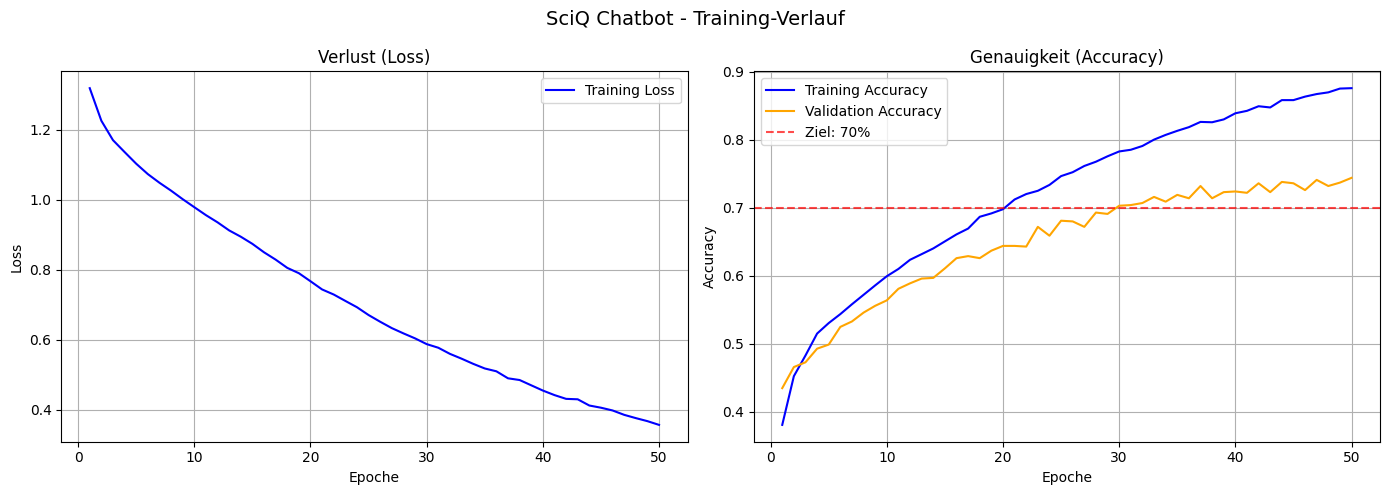

In [29]:
# Training-Verlauf visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(train_losses)+1), train_losses, color='blue', label='Training Loss')
axes[0].set_title('Verlust (Loss)')
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, len(train_accs)+1), train_accs, color='blue',   label='Training Accuracy')
axes[1].plot(range(1, len(val_accs)+1),   val_accs,   color='orange', label='Validation Accuracy')
axes[1].axhline(y=0.70, color='red', linestyle='--', alpha=0.7, label='Ziel: 70%')
axes[1].set_title('Genauigkeit (Accuracy)')
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('SciQ Chatbot - Training-Verlauf', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves_task3.png', dpi=100)
plt.show()

## 13. Finale Evaluation auf Test-Datensatz

In [30]:
# Bestes Modell laden
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
print(f"Bestes Modell geladen: {BEST_MODEL_PATH}")
print()

# Finale Evaluation
final_train_acc = evaluate(model, train_loader, DEVICE)
final_val_acc   = evaluate(model, val_loader,   DEVICE)
final_test_acc  = evaluate(model, test_loader,  DEVICE)

print("="*50)
print("FINALE ERGEBNISSE:")
print("="*50)
print(f"Training Accuracy:   {final_train_acc:.4f} ({final_train_acc*100:.1f}%)")
print(f"Validation Accuracy: {final_val_acc:.4f}   ({final_val_acc*100:.1f}%)")
print(f"Test Accuracy:       {final_test_acc:.4f}  ({final_test_acc*100:.1f}%)")
print()

# Zielprüfung
train_ok = final_train_acc >= 0.70
test_ok  = final_test_acc  >= 0.70
print(f"Ziel ≥70% Training:  {'✓ ERFÜLLT' if train_ok else '✗ nicht erfüllt'}")
print(f"Ziel ≥70% Test:      {'✓ ERFÜLLT' if test_ok  else '✗ nicht erfüllt'}")

if not (train_ok and test_ok):
    print()
    print("Hinweis: Falls Ziel nicht erfüllt, prüfen:")
    print("  1. Wird Support-Text in den Kontext einbezogen? (context_ids = q_ids + s_ids)")
    print("  2. Ist das Label nach Permutation korrekt? (label = perm.index(0))")
    print("  3. Erzeugen leere Texte Nullvektoren statt NaN?")
    print("  4. Hat X Form (B, 4, 3072)?")

Bestes Modell geladen: best_sciq_model.pt

FINALE ERGEBNISSE:
Training Accuracy:   0.9331 (93.3%)
Validation Accuracy: 0.7440   (74.4%)
Test Accuracy:       0.7310  (73.1%)

Ziel ≥70% Training:  ✓ ERFÜLLT
Ziel ≥70% Test:      ✓ ERFÜLLT


## 14. ask_bot Funktion

Verwendet dieselbe Pipeline wie das Training, aber **ohne Permutation** der Antworten.

In [31]:
def ask_bot(question, options, support=""):
    """
    Beantwortet eine Multiple-Choice-Frage mit dem trainierten Modell.
    
    Verwendet dieselbe Pipeline wie das Training:
    - Tokenisierung ohne Special Tokens
    - BERT Eingabe-Embeddings
    - Merkmalsvektor: concat(kontext, antwort, |diff|, produkt)
    
    Im Unterschied zum Training: KEINE Permutation der Antworten.
    
    Args:
        question: str - Die Frage
        options:  list[str] - Genau 4 Antwortoptionen
        support:  str - Optionaler Hintergrundtext (Standard: "")
    
    Ausgabe:
        Gewählte Antwort + Wahrscheinlichkeiten aller 4 Optionen
    """
    assert len(options) == 4, f"Genau 4 Optionen erforderlich, erhalten: {len(options)}"
    
    model.eval()
    
    # Kontextvektor
    q_ids       = tokenize_text(question, MAX_Q)
    s_ids       = tokenize_text(support,  MAX_S)
    context_ids = q_ids + s_ids
    context_vec = mean_embedding(context_ids)  # (768,)
    
    # 4 Merkmalsvektoren (keine Permutation!)
    feat_list = []
    for opt in options:
        a_ids       = tokenize_text(opt, MAX_A)
        answer_vec  = mean_embedding(a_ids)
        feature_vec = build_feature_vector(context_vec, answer_vec)  # (3072,)
        feat_list.append(feature_vec)
    
    # Tensor-Aufbereitung
    X = torch.stack(feat_list, dim=0).unsqueeze(0).float()  # (1, 4, 3072)
    X = X.to(DEVICE)
    
    # Inferenz
    with torch.no_grad():
        logits = model(X)                            # (1, 4)
        probs  = torch.softmax(logits, dim=1)[0]    # (4,)
    
    best_idx = probs.argmax().item()
    chosen   = options[best_idx]
    
    # Ausgabe
    print(f"Frage: {question}")
    if support:
        print(f"Support: {support[:80]}..." if len(support) > 80 else f"Support: {support}")
    print(f"\nGewählte Antwort: {chosen}")
    print("Wahrscheinlichkeiten:")
    for i, (opt, prob) in enumerate(zip(options, probs.tolist())):
        marker = " ← GEWÄHLT" if i == best_idx else ""
        opt_short = opt[:60] + '...' if len(opt) > 60 else opt
        print(f"  [{i}] {opt_short:<63} {prob:.4f}{marker}")
    print()


print("ask_bot() definiert.")

ask_bot() definiert.


## 15. Drei automatische ask_bot-Aufrufe

Zum Abschluss wird `ask_bot` automatisch drei Mal mit Beispielen aus dem Testdatensatz aufgerufen. Vor jedem Aufruf wird die erwartete korrekte Antwort ausgegeben.

In [32]:
def run_three_ask_bot_examples(test_data):
    """
    Ruft ask_bot automatisch mit den ersten 3 Beispielen aus dem Testdatensatz auf.
    Gibt vor jedem Aufruf die erwartete korrekte Antwort aus.
    
    Die Optionen werden in der Reihenfolge [korrekt, distr1, distr2, distr3]
    übergeben (keine Permutation in ask_bot).
    """
    n = min(3, len(test_data))
    
    print("="*70)
    print("AUTOMATISCHE ask_bot-DEMONSTRATION (3 Beispiele aus Testdatensatz)")
    print("="*70)
    print()
    
    for i in range(n):
        ex = test_data[i]
        
        options = [
            ex['correct_answer'],
            ex['distractor1'],
            ex['distractor2'],
            ex['distractor3'],
        ]
        
        print(f"--- Beispiel {i+1} ---")
        print(f"Erwartete korrekte Antwort: {ex['correct_answer']}")
        print()
        
        ask_bot(
            question=ex['question'],
            options=options,
            support=ex.get('support', '')
        )
        
        print("-"*70)
        print()


# Automatischer Aufruf am Ende des Notebooks
run_three_ask_bot_examples(test_split)

AUTOMATISCHE ask_bot-DEMONSTRATION (3 Beispiele aus Testdatensatz)

--- Beispiel 1 ---
Erwartete korrekte Antwort: oxidants

Frage: Compounds that are capable of accepting electrons, such as o 2 or f2, are called what?
Support: Oxidants and Reductants Compounds that are capable of accepting electrons, such ...

Gewählte Antwort: oxidants
Wahrscheinlichkeiten:
  [0] oxidants                                                        0.5378 ← GEWÄHLT
  [1] antioxidants                                                    0.4607
  [2] Oxygen                                                          0.0011
  [3] residues                                                        0.0003

----------------------------------------------------------------------

--- Beispiel 2 ---
Erwartete korrekte Antwort: clone

Frage: What term in biotechnology means a genetically exact copy of an organism?
Support: But transgenic animals just have one novel gene. What about an animal with a who...

Gewählte Antwort: 

## Zusammenfassung

### Implementierte Komponenten

| Komponente | Beschreibung |
|---|---|
| `tokenize_text(text, max_len)` | BERT-Tokenisierung ohne Special Tokens; None/'' → [] |
| `mean_embedding(token_ids)` | Mittlerer Embedding-Vektor; leer → Nullvektor |
| `build_feature_vector(ctx, ans)` | 3072-dim Vektor: concat(ctx, ans, \|diff\|, prod) |
| `SciQDataset` | Dataset mit korrekter Permutations-/Label-Logik |
| `collate_fn` | Baut (B, 4, 3072) Tensoren ohne Padding |
| `ScorecardsMLP` | 3072→512→1 MLP mit ReLU+Dropout |
| `evaluate` | Accuracy-Berechnung ohne Gradienten |
| `ask_bot` | Inferenz mit Softmax-Wahrscheinlichkeiten |

### Wichtige Design-Entscheidungen
- **Nur Input-Embeddings**: BERT-Encoder wird nicht verwendet (nur `get_input_embeddings().weight`)
- **Kein Softmax vor CrossEntropyLoss**: `nn.CrossEntropyLoss` erwartet rohe Logits
- **Kein Padding**: Tokenlisten werden direkt in feste Vektoren umgewandelt
- **Permutations-Label**: `label = perm.index(0)` - neue Position der korrekten Antwort